In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [26]:
df = pd.read_csv('train.csv')

print(f'Dataset Shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Dataset Shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [27]:
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'HalfBath', 'SalePrice']
df_model = df[features].dropna()
df_model = df_model.rename(columns={
    'GrLivArea': 'SquareFootage',
    'BedroomAbvGr': 'Bedrooms',
    'FullBath': 'FullBathrooms',
    'HalfBath': 'HalfBathrooms'})
df_model['Bathrooms'] = df_model['FullBathrooms'] + 0.5 * df_model['HalfBathrooms']
df_model = df_model.drop(columns=['FullBathrooms', 'HalfBathrooms'])
print('📊 Dataset Summary:')
print(df_model.describe())

📊 Dataset Summary:
       SquareFootage     Bedrooms      SalePrice    Bathrooms
count    1460.000000  1460.000000    1460.000000  1460.000000
mean     1515.463699     2.866438  180921.195890     1.756507
std       525.480383     0.815778   79442.502883     0.636015
min       334.000000     0.000000   34900.000000     0.000000
25%      1129.500000     2.000000  129975.000000     1.000000
50%      1464.000000     3.000000  163000.000000     2.000000
75%      1776.750000     3.000000  214000.000000     2.500000
max      5642.000000     8.000000  755000.000000     3.500000


In [28]:
X = df_model[['SquareFootage', 'Bedrooms', 'Bathrooms']]
y = df_model['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [30]:
y_pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print('MODEL EVALUATION RESULTS')
print(f'Mean Absolute Error(MAE):{mae:.2f}')
print(f'Root Mean Sq. Error(RMSE):{rmse:.2f}')
print(f'R² Score:{r2:.4f}')

MODEL EVALUATION RESULTS
Mean Absolute Error(MAE):36569.64
Root Mean Sq. Error(RMSE):53371.56
R² Score:0.6286


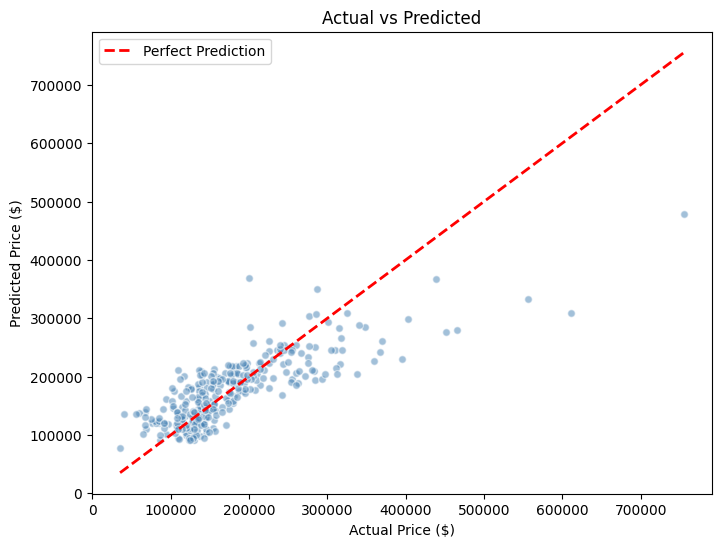

In [31]:
plt.figure(figsize=(8,6))
plt.title('Linear Regression — Prediction Results', fontsize=14, fontweight='bold')
plt.scatter(y_test,y_pred,alpha=0.5,color='steelblue',edgecolor='white',s=30)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--',lw=2,label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'Actual vs Predicted')
plt.legend()
plt.savefig('prediction_results.png')
plt.show()

In [32]:
price1 = model.predict([[1500, 3, 2]])
print(f"1500 sqft,3 bedrooms,2 bathrooms=Price:${price1[0]:,.2f}")
price2 = model.predict([[2500, 4, 3]])
print(f"2500 sqft,4 bedrooms,3 bathrooms=Price:${price2[0]:,.2f}")
price3 = model.predict([[800, 2, 1]])
print(f"800 sqft,2 bedrooms,1 bathroom=Price:${price3[0]:,.2f}")

1500 sqft,3 bedrooms,2 bathrooms=Price:$182,047.74
2500 sqft,4 bedrooms,3 bathrooms=Price:$283,122.31
800 sqft,2 bedrooms,1 bathroom=Price:$111,164.24
